<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan6/blob/main/PCD_Restorasi_Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Foto Model Warna Normal.jpeg to Foto Model Warna Normal (1).jpeg


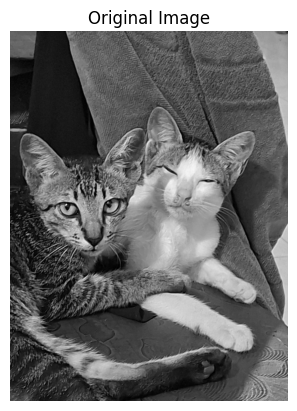

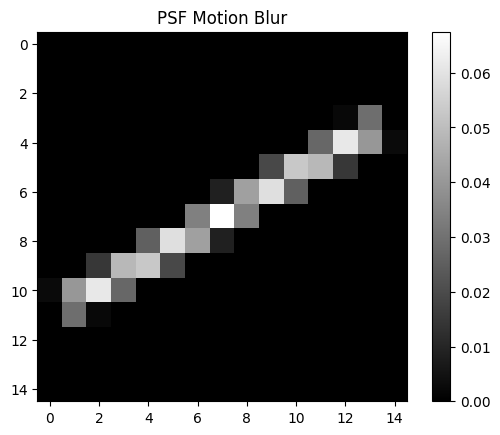

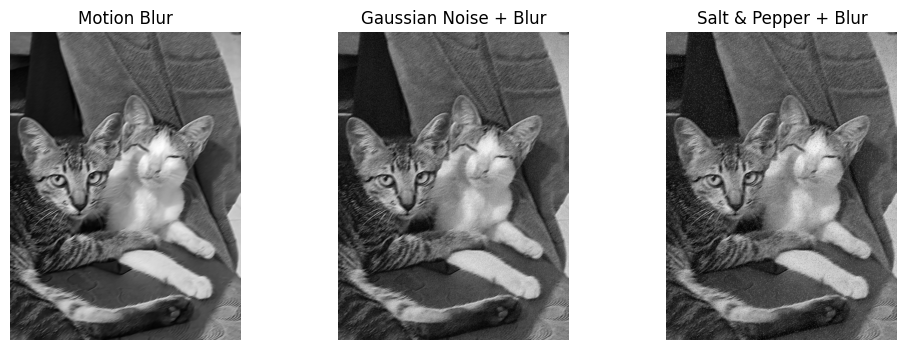

===== MOTION BLUR =====
Inverse : (np.float64(5.886376823147927), np.float64(0.25784713943120685), np.float64(0.009453052225201241))
Wiener  : (np.float64(18.43522690468992), np.float64(0.014337628046726435), np.float64(0.3964418933920904))
Lucy    : (np.float64(23.062672312450033), np.float64(0.004940066199688695), np.float64(0.8580505940651475))

===== GAUSSIAN + BLUR =====
Inverse : (np.float64(3.6287200663712476), np.float64(0.4336386596388563), np.float64(0.0717290666760191))
Wiener  : (np.float64(11.793502353571505), np.float64(0.06616826766599081), np.float64(0.019859267754617833))
Lucy    : (np.float64(15.847000639615484), np.float64(0.026019559270551024), np.float64(0.15292319774771473))

===== SALT PEPPER + BLUR =====
Inverse : (np.float64(3.5548846039110433), np.float64(0.44107408271493986), np.float64(0.13614675082086522))
Wiener  : (np.float64(9.782204652983136), np.float64(0.10514279913040459), np.float64(0.013245995631339436))
Lucy    : (np.float64(14.045647450163044), n

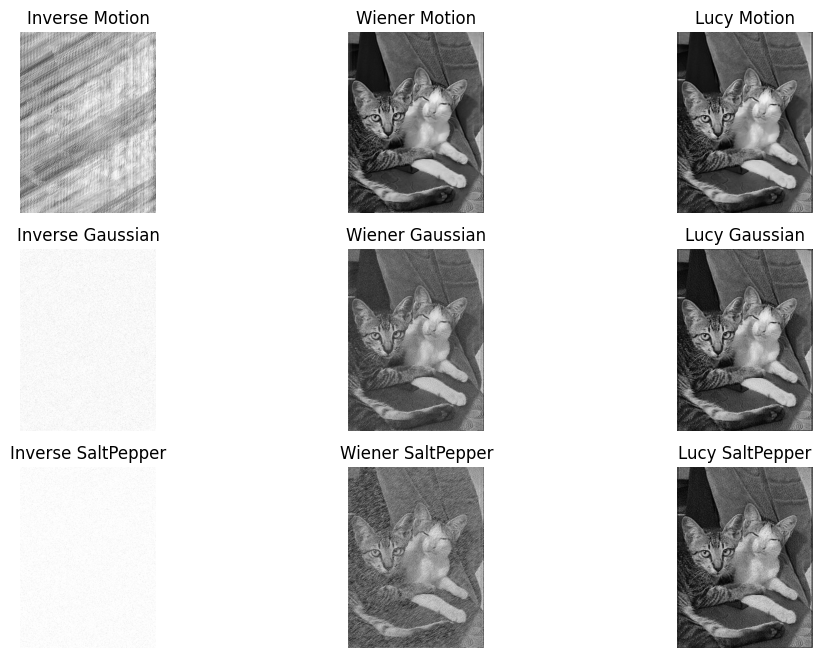

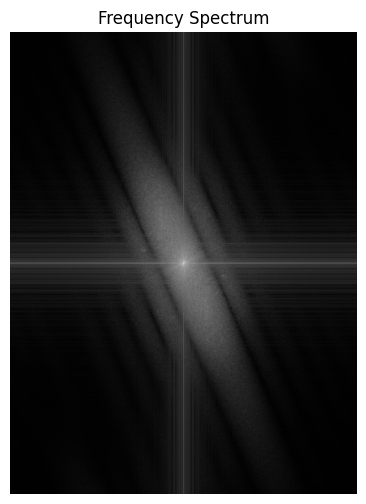

In [3]:
# ================================
# INSTALL LIBRARY
# ================================
!pip install scikit-image opencv-python

# ================================
# IMPORT LIBRARY
# ================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

from scipy.signal import convolve2d
from skimage import img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import structural_similarity as ssim
from skimage.restoration import richardson_lucy

# ================================
# UPLOAD CITRA
# ================================
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
image = img_as_float(image)

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# ================================
# MEMBUAT PSF MOTION BLUR
# panjang = 15 pixel
# sudut = 30 derajat
# ================================
def motion_psf(length, angle):

    psf = np.zeros((length, length))
    center = length // 2

    psf[center, :] = 1

    M = cv2.getRotationMatrix2D((center, center), angle, 1)
    psf = cv2.warpAffine(psf, M, (length, length))

    psf = psf / np.sum(psf)

    return psf

psf = motion_psf(15, 30)

plt.imshow(psf, cmap='gray')
plt.title("PSF Motion Blur")
plt.colorbar()
plt.show()

# ================================
# MEMBUAT DEGRADASI CITRA
# ================================

# Motion blur
blur_motion = convolve2d(image, psf, mode='same', boundary='symm')

# Gaussian noise + blur
gaussian_noise = np.random.normal(0, 20/255, image.shape)

blur_gaussian = convolve2d(image, psf, mode='same', boundary='symm')
blur_gaussian = blur_gaussian + gaussian_noise
blur_gaussian = np.clip(blur_gaussian, 0, 1)

# Salt and pepper + blur
def salt_pepper(img, prob):

    output = np.copy(img)
    rnd = np.random.rand(*img.shape)

    output[rnd < prob/2] = 0
    output[rnd > 1 - prob/2] = 1

    return output

blur_sp = convolve2d(image, psf, mode='same', boundary='symm')
blur_sp = salt_pepper(blur_sp, 0.05)

# ================================
# MENAMPILKAN CITRA DEGRADASI
# ================================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(blur_motion, cmap='gray')
plt.title("Motion Blur")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(blur_gaussian, cmap='gray')
plt.title("Gaussian Noise + Blur")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(blur_sp, cmap='gray')
plt.title("Salt & Pepper + Blur")
plt.axis('off')

plt.show()

# ================================
# INVERSE FILTER
# ================================
def inverse_filter(img, psf):

    eps = 1e-3

    G = np.fft.fft2(img)
    H = np.fft.fft2(psf, s=img.shape)

    F_hat = G / (H + eps)

    result = np.abs(np.fft.ifft2(F_hat))
    result = np.clip(result,0,1)

    return result

# ================================
# WIENER FILTER
# ================================
def wiener_filter(img, psf, K=0.01):

    G = np.fft.fft2(img)
    H = np.fft.fft2(psf, s=img.shape)

    H_conj = np.conj(H)

    F_hat = (H_conj / (np.abs(H)**2 + K)) * G

    result = np.abs(np.fft.ifft2(F_hat))
    result = np.clip(result,0,1)

    return result

# ================================
# LUCY RICHARDSON
# ================================
def lucy_richardson_filter(img, psf):

    result = richardson_lucy(img, psf, num_iter=30)
    result = np.clip(result,0,1)

    return result

# ================================
# RESTORASI + WAKTU KOMPUTASI
# ================================
def restore_all(img):

    start = time.time()
    inv = inverse_filter(img, psf)
    t1 = time.time() - start

    start = time.time()
    wnr = wiener_filter(img, psf)
    t2 = time.time() - start

    start = time.time()
    lucy = lucy_richardson_filter(img, psf)
    t3 = time.time() - start

    return inv, wnr, lucy, t1, t2, t3

inv1, wnr1, lucy1, t1,t2,t3 = restore_all(blur_motion)
inv2, wnr2, lucy2, t4,t5,t6 = restore_all(blur_gaussian)
inv3, wnr3, lucy3, t7,t8,t9 = restore_all(blur_sp)

# ================================
# EVALUASI METRIK
# ================================
def evaluate(original, restored):

    return (
        psnr(original, restored, data_range=1),
        mse(original, restored),
        ssim(original, restored, data_range=1)
    )

print("===== MOTION BLUR =====")
print("Inverse :", evaluate(image, inv1))
print("Wiener  :", evaluate(image, wnr1))
print("Lucy    :", evaluate(image, lucy1))

print("\n===== GAUSSIAN + BLUR =====")
print("Inverse :", evaluate(image, inv2))
print("Wiener  :", evaluate(image, wnr2))
print("Lucy    :", evaluate(image, lucy2))

print("\n===== SALT PEPPER + BLUR =====")
print("Inverse :", evaluate(image, inv3))
print("Wiener  :", evaluate(image, wnr3))
print("Lucy    :", evaluate(image, lucy3))

# ================================
# VISUALISASI HASIL RESTORASI
# ================================
plt.figure(figsize=(12,8))

images = [inv1, wnr1, lucy1, inv2, wnr2, lucy2, inv3, wnr3, lucy3]
titles = [
"Inverse Motion","Wiener Motion","Lucy Motion",
"Inverse Gaussian","Wiener Gaussian","Lucy Gaussian",
"Inverse SaltPepper","Wiener SaltPepper","Lucy SaltPepper"
]

for i in range(9):

    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

# ================================
# SPEKTRUM FREKUENSI
# ================================
def show_spectrum(img):

    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    spectrum = np.log(np.abs(fshift)+1)

    plt.imshow(spectrum, cmap='gray')
    plt.title("Frequency Spectrum")
    plt.axis('off')

plt.figure(figsize=(6,6))
show_spectrum(blur_motion)
plt.show()